Step 1 : Data Cleaning
You have collected your data! So it's time to do a cleaning on it. A cleaned dataset is a dataset that doesn't contain any duplicates, is blank spaces or error-free. The rest of the analysis can be discarded if you neglect this step!

No duplicates
No blank spaces (ex: " I love python " => "I love python")
No errors
No empty values

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "../analysis_KLITI/data/processed/cleaned_listings.csv", skipinitialspace=True, na_values=["None"]
)

How many rows and columns?

In [3]:
df.shape

(23202, 23)

What is the correlation between the variables and the price? (Why might that be?)

In [ ]:
df.select_dtypes(include="number").drop(columns=["postal_code"]).corr()[
    "price_eur"
]  # not including postal code

price_eur                 1.000000
num_rooms                 0.418902
living_area_m2            0.571312
fully_equipped_kitchen    0.067800
furnished                 0.021156
terrace                   0.136913
terrace_area_m2           0.219484
garden                    0.150069
garden_area_m2            0.256721
land_surface_m2           0.333986
num_facades               0.204266
swimming_pool             0.228295
price_per_m2              0.436294
avg_price_locality        0.543683
building_state_encoded    0.230461
Name: price_eur, dtype: float64

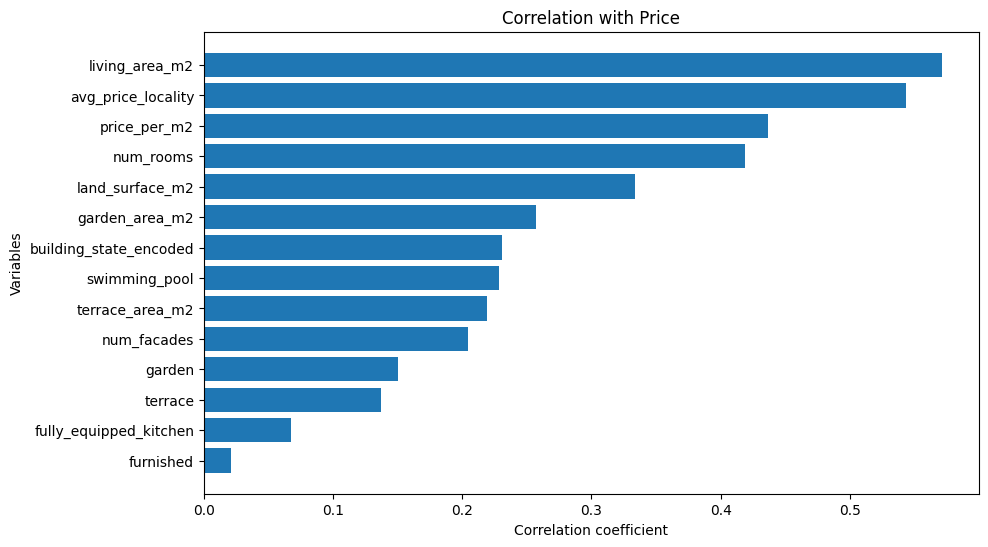

In [ ]:
corr = (
    df.select_dtypes(include="number")
    .drop(columns=["postal_code"])
    .corr()["price_eur"]
    .drop("price_eur")
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(corr.index, corr.values)
plt.title("Correlation with Price")
plt.xlabel("Correlation coefficient")
plt.ylabel("Variables")
plt.show()

How are variables correlated to each other? (Why?)

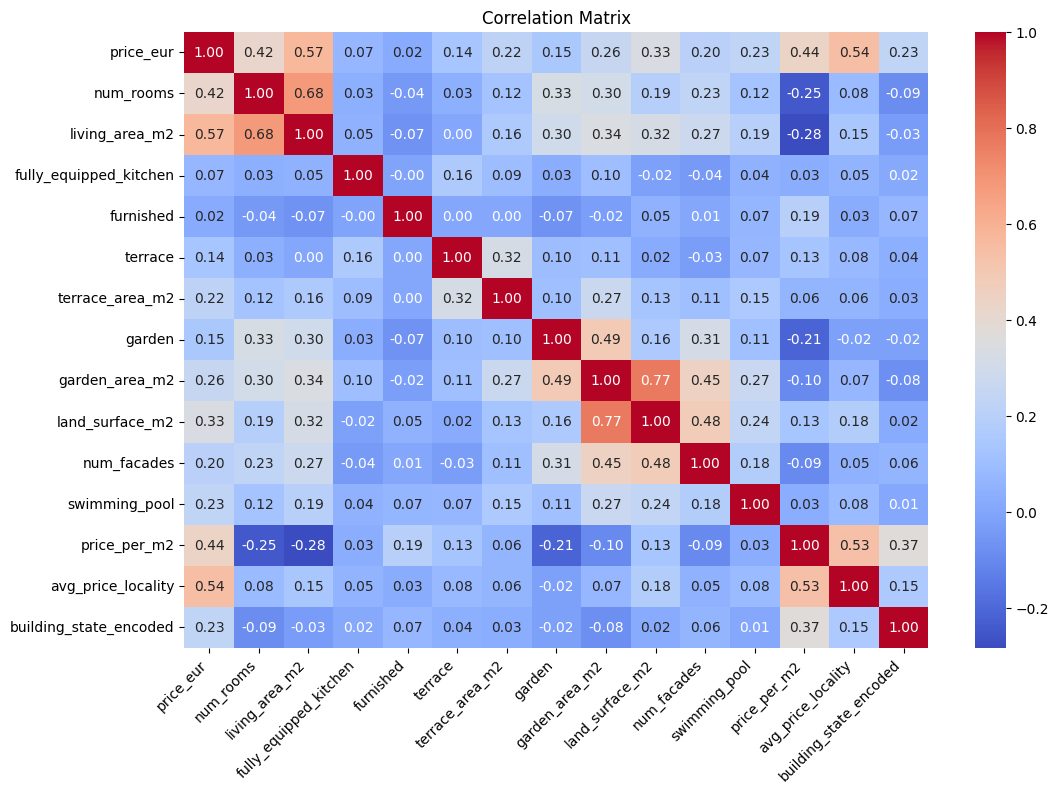

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.select_dtypes(include="number").drop(columns=["postal_code"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.show()

## Correlation Analysis

### Strongest correlations with price:
- Living area and location have nearly the same strong correlation. as expected these two are the most important ones. In third comes number of rooms but thats related to living area.
- Furnished and kitchen state have the lowest correlation with the price. People seems to care less about these two.
### Interesting correlations between variables:
- Garden and number of facades seems to be strong related because properties with garden tend to be villas with 4 facades.
- Furnished has nearly 0 correlation with everything because is a personal choice and has nothing to do with the properties physical characteriscs.
- Building state and price only .2 This tells us that a run down villa in Brussels can still be more expensive than renovated one in rural areas. Location and size are more important than the property state.

### Weak/no correlations:
- Kitchen state seems to be weak with relation to everything else. It might be because we had a lot of properties without that information, but looking at furnished that is also weak it means that it remains a personal choice.

### Conclusions:
- When it comes to properties prices in Belgium the most important characteristics are size and location. No matter what state is the building or if it's furnished or not.

Percentage of missing values per column?

In [7]:
df.isnull().mean() * 100

locality                   0.000000
property_type              0.000000
subtype                    0.000000
price_eur                  0.000000
type_of_sale               0.000000
num_rooms                  1.620550
living_area_m2             0.000000
fully_equipped_kitchen     0.000000
furnished                 38.996638
terrace                    0.000000
terrace_area_m2           32.311870
garden                     0.000000
garden_area_m2            34.104819
land_surface_m2           48.577709
num_facades               22.136023
swimming_pool              0.000000
state_of_building         21.105939
price_per_m2               0.000000
postal_code                0.000000
region                     0.000000
outlier_flag               0.000000
avg_price_locality         0.000000
building_state_encoded    21.105939
dtype: float64

### Plot the outliers.


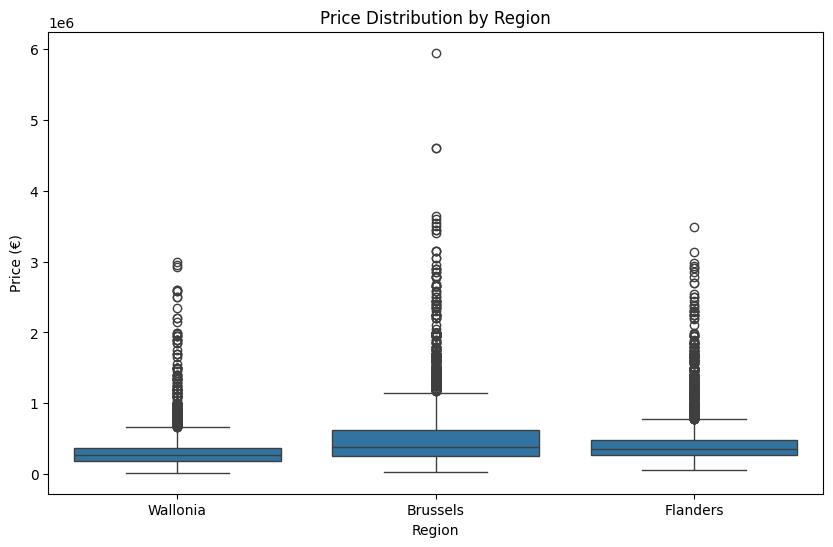

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="region", y="price_eur")
plt.title("Price Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Price (€)")
plt.show()

### Observation
- Brussels has the highest median price followed closely by Flanders.
- Wallonia has the lowest median price
- Brussels has the widest box which means that prices vary more. It has a greater price variability
- All regions have many high price outliers but Brussels has the most extreme ones reaching nearly 6 million.

### What we get from this?
- We have a strong luxury market in Brussels that can be also diplomatic properties which make the price go higher.
- The lowest median price that is in Wallonia might be because it has more rural areas.
- Flanders is the most industrialized region, for this reason, the median price is higher than wallonia. Another reason is that Flanders has the most number of tourists with 63% of total overnight stays.

Represent the number of properties according to their surface using a histogram.

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df["living_area_m2"].dropna(), bins=50)
plt.title("Number of Properties by Living Area")
plt.xlabel("Living Area (m²)")
plt.ylabel("Number of Properties")
plt.show()

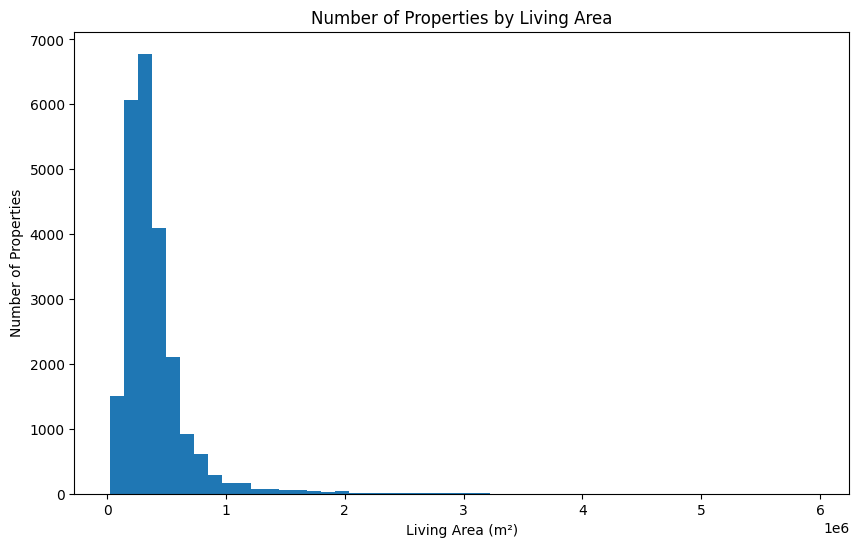

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df["price_eur"].dropna(), bins=50)
plt.title("Number of Properties by Living Area")
plt.xlabel("Living Area (m²)")
plt.ylabel("Number of Properties")
plt.show()

### What we get ?
We see that most of the properties are between 100-150 m2. This is the sweet spot between affordable and comfortable. Also the typical Belgian family is 2 - 4 persons, so developers build more properties in this range because they sell faster.

### Which 5 variables are the most important and why?

In my opinion 5 most important variables based also in the analysis that we did are:
- Living area (directly determines how much space you get for your money)
- Locality (closer to big cities the higher the price will be)
- Number of rooms (a family of 4 will prefer a property divided in at least 3 rooms even if the living area might be the same as a 1 room property. More rooms > Higher Price)
- Land surface (bigger land surface means more privacy and better opportunities to upgrade in the future)
- State of the building (better state of the building is directly connected to the total price you will have to pay. Also you can occupy that property faster without waiting for the renovation to finish first)

In our correlation chart we see that area of the garden is more correlated with the price than the state of the building. This doesn't indicate that the state of the building is less important but because garden area is strongly connected with land surface it makes it to stand higher in our chart.



What are the most expensive municipalities in Belgium? (Average price, median price, price per square meter)

In [10]:
#AVERAGE price per municipaltiy
df.groupby('locality')['price_eur'].agg(['mean', 'count']).query('count >= 10').sort_values('mean', ascending=False).head(10).round(2) #check the mean for at least 10 lisitngs

,mean,count
locality,,
8300 Knokke,1090371.79,39
1950 Kraainem,1069244.44,36
1933 Sterrebeek,1035171.43,35
8300 Knokke-Heist,861553.64,55
1640 Sint-Genesius-Rode,854000.00,53
1150 Sint-Pieters-Woluwe,850611.43,175
3080 Tervuren,803059.64,28
1180 Ukkel,790087.13,426
2970 Schilde,779806.00,14


In [11]:
#MEDIAN price per municipaltiy
df.groupby('locality')['price_eur'].agg(['median', 'count']).query('count >= 10').sort_values('median', ascending=False).head(10).round(2)

,median,count
locality,,
1950 Kraainem,995000.0,36
1933 Sterrebeek,849000.0,35
8300 Knokke-Heist,830000.0,55
8300 Knokke,795000.0,39
3080 Tervuren,696000.0,28
1380 Lasne,695000.0,43
1150 Sint-Pieters-Woluwe,685000.0,175
2820 Bonheiden,679350.0,18
1640 Sint-Genesius-Rode,675000.0,53


In [12]:
#PRICE per sqm
df.groupby('locality')['price_per_m2'].agg(['median', 'count']).query('count >= 10').sort_values('median', ascending=False).head(10).round(2)

,median,count
locality,,
8300 Knokke,9112.90,39
8300 Knokke-Heist,7666.67,55
8301 Duinbergen,6973.32,48
9830 Sint-Martens-Latem,5432.69,13
3000 Leuven,5000.00,53
1160 Oudergem,4629.63,131
1200 Sint-Lambrechts-Woluwe,4555.21,274
8620 Nieuwpoort,4540.23,97
1050 Elsene,4531.34,376


In [ ]:
# all three queries in one table
df.groupby("locality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("price_eur", "count"),
).query("count >= 10").sort_values("avg_price", ascending=False).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
5542 Blaimont,86340.91,66750.0,1574.07,22
5540 Hastière-Lavaux,97315.38,89000.0,1483.33,13
7340 Colfontaine,143910.34,139000.0,1000.00,29
7370 Élouges,147718.18,110000.0,854.70,11
6030 Marchienne-au-Pont,155043.50,159499.5,938.78,32
4102 Ougrée,160512.50,177000.0,1594.88,32
7110 Houdeng-Aimeries,164090.73,159000.0,1078.31,11
7390 Quaregnon,172267.59,165000.0,1117.65,17
6061 Montignies-sur-Sambre,174299.93,170000.0,1281.25,43


What are the most expensive municipalities in Wallonia? (Average price, median price, price per square meter)

In [14]:
df[df['region'] == 'Wallonia'].groupby('locality').agg(
    avg_price=('price_eur', 'mean'),
    median_price=('price_eur', 'median'),
    price_per_m2=('price_per_m2', 'median'),
    count=('price_eur', 'count')
).query('count >= 10').sort_values('avg_price', ascending=False).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
1380 Lasne,708837.65,695000.0,3090.91,43
1310 La Hulpe,700400.00,545000.0,3166.67,15
6210 Les Bons Villers,691178.50,364376.0,2443.26,10
1410 Waterloo,651337.79,535000.0,3442.31,131
1332 Genval,646590.91,552500.0,3396.90,22
1325 Chaumont-Gistoux,628941.21,662500.0,2959.44,24
1420 Braine-l'Alleud,598900.69,470300.0,3198.48,70
1330 Rixensart,597346.94,545000.0,3120.19,49
1390 Grez-Doiceau,559528.16,399500.0,2872.28,38


What are the most expensive municipalities in Flanders? (Average price, median price, price per square meter)

In [15]:
df[df['region'] == 'Flanders'].groupby('locality').agg(
    avg_price=('price_eur', 'mean'),
    median_price=('price_eur', 'median'),
    price_per_m2=('price_per_m2', 'median'),
    count=('price_eur', 'count')
).query('count >= 10').sort_values('avg_price', ascending=False).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
8300 Knokke,1090371.79,795000.0,9112.90,39
1950 Kraainem,1069244.44,995000.0,4057.62,36
1933 Sterrebeek,1035171.43,849000.0,4087.72,35
8300 Knokke-Heist,861553.64,830000.0,7666.67,55
1640 Sint-Genesius-Rode,854000.00,675000.0,3333.33,53
3080 Tervuren,803059.64,696000.0,3583.34,28
2970 Schilde,779806.00,643130.5,3452.68,14
1970 Wezembeek-Oppem,733650.00,672500.0,3754.31,20
2820 Bonheiden,724611.28,679350.0,2891.04,18


What are the less expensive municipalities in Belgium? (Average price, median price, price per square meter)

In [ ]:
df.groupby("locality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("price_eur", "count"),
).query("count >= 10").sort_values("avg_price", ascending=True).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
5542 Blaimont,86340.91,66750.0,1574.07,22
5540 Hastière-Lavaux,97315.38,89000.0,1483.33,13
7340 Colfontaine,143910.34,139000.0,1000.00,29
7370 Élouges,147718.18,110000.0,854.70,11
6030 Marchienne-au-Pont,155043.50,159499.5,938.78,32
4102 Ougrée,160512.50,177000.0,1594.88,32
7110 Houdeng-Aimeries,164090.73,159000.0,1078.31,11
7390 Quaregnon,172267.59,165000.0,1117.65,17
6061 Montignies-sur-Sambre,174299.93,170000.0,1281.25,43


What are the less expensive municipalities in Wallonia? (Average price, median price, price per square meter)

In [17]:
df[df['region'] == 'Wallonia'].groupby('locality').agg(
    avg_price=('price_eur', 'mean'),
    median_price=('price_eur', 'median'),
    price_per_m2=('price_per_m2', 'median'),
    count=('price_eur', 'count')
).query('count >= 10').sort_values('avg_price', ascending=True).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
5542 Blaimont,86340.91,66750.0,1574.07,22
5540 Hastière-Lavaux,97315.38,89000.0,1483.33,13
7340 Colfontaine,143910.34,139000.0,1000.00,29
7370 Élouges,147718.18,110000.0,854.70,11
6030 Marchienne-au-Pont,155043.50,159499.5,938.78,32
4102 Ougrée,160512.50,177000.0,1594.88,32
7110 Houdeng-Aimeries,164090.73,159000.0,1078.31,11
7390 Quaregnon,172267.59,165000.0,1117.65,17
6061 Montignies-sur-Sambre,174299.93,170000.0,1281.25,43


What are the less expensive municipalities in Flanders? (Average price, median price, price per square meter)

In [18]:
df[df['region'] == 'Flanders'].groupby('locality').agg(
    avg_price=('price_eur', 'mean'),
    median_price=('price_eur', 'median'),
    price_per_m2=('price_per_m2', 'median'),
    count=('price_eur', 'count')
).query('count >= 10').sort_values('avg_price', ascending=True).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
8940 Wervik,208313.90,199000.0,1073.53,29
8890 Moorslede,222272.73,165000.0,1687.50,11
8780 Oostrozebeke,231700.00,216500.0,1906.86,10
8430 Middelkerke,247778.26,249000.0,3873.24,23
3690 Zutendaal,258849.07,265000.0,2226.89,15
3700 Berg,260427.27,249000.0,1617.77,22
8930 Menen,261216.67,204000.0,1219.76,36
2100 Deurne,263758.88,238000.0,2513.04,107
2140 Borgerhout,264604.35,242000.0,2549.57,46
